# Price forecast model comparison

Which model should produce the day-ahead price forecasts on the dashboard, and why?

**Setup.** Every model forecasts each quarter-hour of the next local day at 11:40 on
the day before, using only information published by then (see
`src/forecasting/information.py`). Forecasts are walk-forward: a model never sees
the day it forecasts. Scores cover the validation window, 1 June 2024 to 31 May
2026. The hold-out from 1 June 2026 is not touched here.

**Candidates.**

| Model | Idea | Reference |
|---|---|---|
| `lear` | Sparse linear model on arcsinh-scaled prices, conformal ranges | LEAR, Lago et al. 2021 |
| `lightgbm_quantile` | One gradient-boosted model per quantile, pinball loss | Widely used quantile GBM |
| `lightgbm_conformal` | Gradient-boosted median model, conformal ranges per hour | Split conformal prediction |
| `quantile_forest` | Random forest keeping leaf prices, any quantile | Meinshausen 2006 |
| `mstl` | Daily and weekly seasonal decomposition of recent prices | statsforecast MSTL |
| `qra` | Regularized quantile regression on the other models' medians | Nowotarski and Weron 2015; Uniejewski and Weron 2021 |
| `naive_previous_day`, `seasonal_naive_previous_week` | Baselines to beat | Phase 1 |

**Selection rules** (docs/decisions.md): lowest mean pinball loss on the validation
window; honest coverage of the 50%, 80% and 90% ranges; performance on the
15-minute months, negative-price days and spike days; a Diebold-Mariano test so a
win is not noise; run time that fits the 11:40 deadline; a near tie goes to the
simpler, better calibrated model. Phase 4 re-checks the top models on trading profit.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import REPO_ROOT, load_settings
from src.forecasting.base import quantile_column
from src.forecasting.evaluate import daily_pinball, diebold_mariano, pinball, score, segment_scores
from src.forecasting.walkforward import day_range

warnings.filterwarnings("ignore")
settings = load_settings()
QUANTILES = settings.forecasting.quantiles
FORECASTS = settings.data.processed_path / "forecasts" / "comparison"
ORDER = ["lear", "lightgbm_quantile", "lightgbm_conformal", "quantile_forest", "mstl", "qra",
         "naive_previous_day", "seasonal_naive_previous_week"]
COLORS = dict(zip(ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7",
                           "#898781", "#c3c2b7"], strict=True))
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "font.size": 9})

runs = {}
for name in ORDER:
    path = FORECASTS / f"{name}.parquet"
    if path.exists():
        table = pd.read_parquet(path)
        runs[name] = table[[d >= settings.evaluation.validation_start for d in table["target_day"]]]
print({name: f"{t['target_day'].nunique()} days" for name, t in runs.items()})


{'lear': '730 days', 'lightgbm_quantile': '730 days', 'lightgbm_conformal': '730 days', 'quantile_forest': '730 days', 'mstl': '730 days', 'qra': '730 days', 'naive_previous_day': '730 days', 'seasonal_naive_previous_week': '730 days'}


## Overall scores on the validation window

Sorted by mean pinball loss, lower is better. Coverage should be close to the nominal level.

In [2]:
rows = {}
naive = score(runs["naive_previous_day"], QUANTILES)["mean pinball"]
for name, table in runs.items():
    s = score(table, QUANTILES)
    valid = table[table["actual"].notna()]
    crossings = int(table["crossings_repaired"].groupby(table["target_day"]).first().sum())
    rows[name] = {
        "mean pinball": round(s["mean pinball"], 2),
        "vs naive": f"{s['mean pinball'] / naive - 1:+.1%}",
        "MAE of median": round(s["MAE of median"], 2),
        "RMSE of median": round(s["RMSE of median"], 2),
        "coverage 50%": f"{s['coverage 50%']:.1%}",
        "coverage 80%": f"{s['coverage 80%']:.1%}",
        "coverage 90%": f"{s['coverage 90%']:.1%}",
        "median width 90%": round(float((valid["q95"] - valid["q05"]).median()), 1),
        "periods with crossed quantiles": crossings,
    }
overall = pd.DataFrame(rows).T.sort_values("mean pinball")
overall


,mean pinball,vs naive,MAE of median,RMSE of median,coverage 50%,coverage 80%,coverage 90%,median width 90%,periods with crossed quantiles
lightgbm_quantile,5.0,-47.9%,15.43,27.61,30.3%,56.8%,73.3%,40.7,47184
lightgbm_conformal,5.11,-46.8%,16.03,27.9,48.6%,76.3%,85.6%,58.7,0
quantile_forest,5.18,-46.1%,16.8,30.72,59.7%,87.6%,94.6%,82.0,0
qra,5.21,-45.8%,15.6,27.89,48.7%,78.1%,88.9%,72.5,3522
mstl,7.74,-19.4%,22.69,36.71,69.6%,89.8%,94.4%,128.2,0
lear,8.06,-16.1%,24.59,62.54,45.7%,75.7%,84.9%,82.5,0
naive_previous_day,9.61,+0.0%,29.05,46.11,48.0%,78.5%,86.4%,128.6,0
seasonal_naive_previous_week,11.49,+19.6%,35.34,56.82,47.7%,77.6%,85.4%,136.4,0


## Mean pinball loss by segment

The 15-minute months, negative-price days and spike days are where trading value concentrates.

In [3]:
segments = pd.DataFrame({
    name: segment_scores(table, settings)["mean pinball"].round(2) for name, table in runs.items()
}).T
segments = segments.drop(columns=["Validation window"]).loc[overall.index]
segments


,All target days,15-minute products,Days with a negative price,Days with a price above €200
lightgbm_quantile,5.00,4.70,5.43,7.78
lightgbm_conformal,5.11,4.96,5.17,8.20
quantile_forest,5.18,4.91,5.29,8.11
qra,5.21,4.91,5.49,8.74
mstl,7.74,7.81,7.86,10.01
lear,8.06,8.29,9.56,12.67
naive_previous_day,9.61,9.49,10.13,13.57
seasonal_naive_previous_week,11.49,11.81,11.24,14.03


## Stability over time

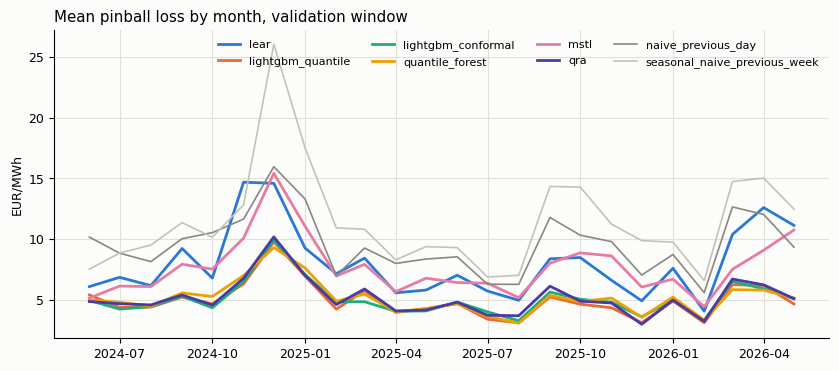

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, table in runs.items():
    daily = daily_pinball(table, QUANTILES)
    monthly = daily.groupby([pd.Timestamp(d).to_period("M") for d in daily.index]).mean()
    ax.plot(monthly.index.to_timestamp(), monthly.to_numpy(), label=name, color=COLORS[name],
            linewidth=2 if not name.startswith(("naive", "seasonal")) else 1.2)
ax.set_title("Mean pinball loss by month, validation window", loc="left")
ax.set_ylabel("EUR/MWh")
ax.legend(ncols=4, frameon=False, fontsize=8)
plt.show()


## Calibration

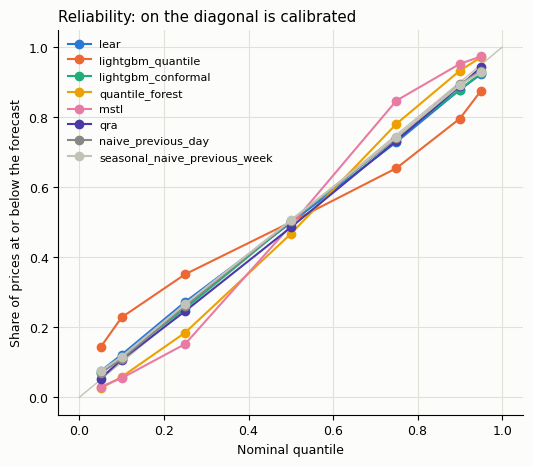

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1)
for name, table in runs.items():
    valid = table[table["actual"].notna()]
    empirical = [float(np.mean(valid["actual"] <= valid[quantile_column(q)])) for q in QUANTILES]
    ax.plot(QUANTILES, empirical, marker="o", color=COLORS[name], label=name, linewidth=1.5)
ax.set_xlabel("Nominal quantile")
ax.set_ylabel("Share of prices at or below the forecast")
ax.set_title("Reliability: on the diagonal is calibrated", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.show()


Share of prices at or below each forecast quantile. A calibrated model matches the quantile level.

In [6]:
shares = {}
for name, table in runs.items():
    valid = table[table["actual"].notna()]
    shares[name] = {
        f"q{round(q * 100):02d}": f"{np.mean(valid['actual'] <= valid[quantile_column(q)]):.1%}"
        for q in QUANTILES
    }
pd.DataFrame(shares).T.loc[overall.index]


,q05,q10,q25,q50,q75,q90,q95
lightgbm_quantile,14.3%,22.8%,35.1%,50.0%,65.5%,79.6%,87.6%
lightgbm_conformal,7.0%,11.5%,25.4%,50.3%,74.0%,87.8%,92.7%
quantile_forest,2.5%,5.8%,18.4%,46.7%,78.1%,93.3%,97.1%
qra,5.3%,10.7%,24.6%,48.5%,73.3%,88.9%,94.3%
mstl,3.0%,5.5%,15.2%,49.0%,84.8%,95.2%,97.4%
lear,7.4%,12.2%,27.2%,49.8%,72.9%,87.9%,92.3%
naive_previous_day,6.9%,10.9%,26.1%,50.4%,74.1%,89.4%,93.3%
seasonal_naive_previous_week,7.5%,11.6%,26.6%,50.5%,74.3%,89.2%,92.9%


## Error by hour of day

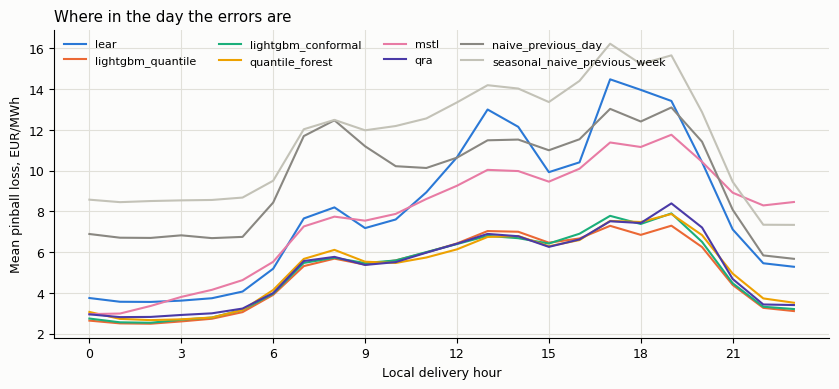

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, table in runs.items():
    valid = table[table["actual"].notna()]
    actual = valid["actual"].to_numpy()
    loss = np.mean([pinball(actual, valid[quantile_column(q)].to_numpy(), q) for q in QUANTILES], axis=0)
    hours = pd.DatetimeIndex(valid.index).tz_convert(settings.market.timezone).hour
    ax.plot(range(24), pd.Series(loss).groupby(hours).mean().to_numpy(), color=COLORS[name], label=name)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Local delivery hour")
ax.set_ylabel("Mean pinball loss, EUR/MWh")
ax.set_title("Where in the day the errors are", loc="left")
ax.legend(ncols=4, frameon=False, fontsize=8)
plt.show()


## Is a win significant?

Diebold-Mariano test on daily mean pinball loss, Newey-West variance over seven days. First against the lowest-loss model:

In [8]:
def dm_table(reference):
    """Diebold-Mariano test of every model against ``reference`` on daily pinball loss."""
    ref = daily_pinball(runs[reference], QUANTILES)
    calendar = day_range(min(ref.index), max(ref.index))
    rows = {}
    for name, table in runs.items():
        if name == reference:
            continue
        other = daily_pinball(table, QUANTILES).reindex(calendar).to_numpy()
        statistic, p_value = diebold_mariano(other, ref.reindex(calendar).to_numpy())
        rows[name] = {"DM statistic, positive means worse": round(statistic, 2),
                      "p-value": f"{p_value:.4f}"}
    return pd.DataFrame(rows).T


best = overall.index[0]
chosen = settings.forecasting.production_model
print(f"Lowest mean pinball loss: {best}. Production model: {chosen}.")
dm_table(best)


Lowest mean pinball loss: lightgbm_quantile. Production model: lightgbm_conformal.


,"DM statistic, positive means worse",p-value
lear,8.59,0.0000
lightgbm_conformal,1.59,0.1118
quantile_forest,2.93,0.0034
mstl,15.74,0.0000
qra,3.26,0.0011
naive_previous_day,19.97,0.0000
seasonal_naive_previous_week,14.0,0.0000


Then against the production model:

In [9]:
dm_table(chosen)


,"DM statistic, positive means worse",p-value
lear,8.5,0.0000
lightgbm_quantile,-1.59,0.1118
quantile_forest,0.89,0.3712
mstl,15.99,0.0000
qra,1.8,0.0713
naive_previous_day,19.41,0.0000
seasonal_naive_previous_week,14.03,0.0000


## Run time

In [10]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{REPO_ROOT / 'mlflow.db'}")
found = mlflow.search_runs(experiment_names=["price-forecast-comparison"], order_by=["start_time DESC"])
columns = {"tags.model": "model", "metrics.run_seconds": "run seconds",
           "params.refit_every_days": "refit every days"}
if found.empty:
    runtime = pd.DataFrame(columns=list(columns.values()))
else:
    runtime = found.drop_duplicates("tags.model")[list(columns)].rename(columns=columns).set_index("model")
runtime


,run seconds,refit every days
model,,
qra,362.348214,7
lightgbm_conformal,706.080230,28
mstl,2681.857273,1
lear,98.559932,28
quantile_forest,334.436809,28
lightgbm_quantile,1077.627336,28
seasonal_naive_previous_week,9.690851,1
naive_previous_day,9.348401,1


## Decision: LightGBM conformal goes to production

| model | mean pinball | vs naive | 90% range coverage | median 90% width, EUR/MWh | crossed periods |
|---|---|---|---|---|---|
| lightgbm_quantile | 5.00 | -47.9% | 73.3% | 40.7 | 47,184 |
| **lightgbm_conformal** | **5.11** | **-46.8%** | **85.6%** | **58.7** | **0** |
| quantile_forest | 5.18 | -46.1% | 94.6% | 82.0 | 0 |
| qra | 5.21 | -45.8% | 88.9% | 72.5 | 3,522 |
| mstl | 7.74 | -19.4% | 94.4% | 128.2 | 0 |
| lear | 8.06 | -16.1% | 84.9% | 82.5 | 0 |
| naive_previous_day | 9.61 | +0.0% | 86.4% | 128.6 | 0 |
| seasonal_naive_previous_week | 11.49 | +19.6% | 85.4% | 136.4 | 0 |

All figures are from the tables above.

**Why LightGBM conformal.**

1. **It ties for the best accuracy.** Tested against it, LightGBM quantile gives p = 0.11 and the
   quantile forest p = 0.37: neither difference is significant. It is 46.8% better than naive.
2. **Its ranges are close to honest.** Prices fall below its q05 to q95 forecasts 7.0%, 11.5%, 25.4%,
   50.3%, 74.0%, 87.8% and 92.7% of the time, against targets of 5% to 95%.
3. **Its ranges are sharp.** The median 90% range is 58.7 EUR/MWh wide, against 82.0 for the quantile
   forest, which covers more than it should, and 72.5 for QRA.
4. **It never crosses quantiles and is a single model**, simple to run before the 11:40 deadline.

**Why not the others.**

- **LightGBM quantile** has the lowest loss, but its ranges are overconfident: its 90% range covers only
  73.3% of prices and its quantiles crossed in two thirds of all periods. On the dashboard that would
  understate spike and negative-price risk, the most expensive error for a battery.
- **QRA** is well calibrated, but it is not more accurate than LightGBM conformal (p = 0.07), it is
  worse on spike days, 8.74 against 8.20, and it needs all five member models running every day.
- **The quantile forest** is the conservative alternative: accurate, never crossing, but wider than needed.

**Weaknesses to watch.** The tails are slightly narrow, 85.6% coverage for a 90% range. On spike days
LightGBM quantile is better, 7.78 against 8.20. Hyperparameters are defaults, not tuned. Phase 4
re-checks the top three models on trading profit, and Phase 6 monitors coverage drift.
